In [2]:
print("hello")

hello


--- TASK 1: CREATING DATASET ---
First 5 records of initial dataset:
   Patient ID   Age  Gender  Height (cm)  Weight (kg)  Systolic BP  \
0         101  45.0    Male          175           82          135   
1         102  34.0  Female          160           65          118   
2         103  61.0    Male          168           88          145   
3         104  29.0  Female          165           54          110   
4         105  52.0    Male          180           95          150   

   Diastolic BP  Blood Sugar (mg/dL)  Physical Activity (hrs/wk)  \
0            88                  110                         2.5   
1            76                   92                         4.0   
2            92                  145                         1.0   
3            70                   85                         5.0   
4            95                  160                         0.5   

  Smoking Status  
0            Yes  
1             No  
2            Yes  
3             No  
4     

/tmp/ipykernel_576/2908003347.py:226: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Overall Health Risk', order=risk_order, ax=axes[0, 1], palette='Set2')


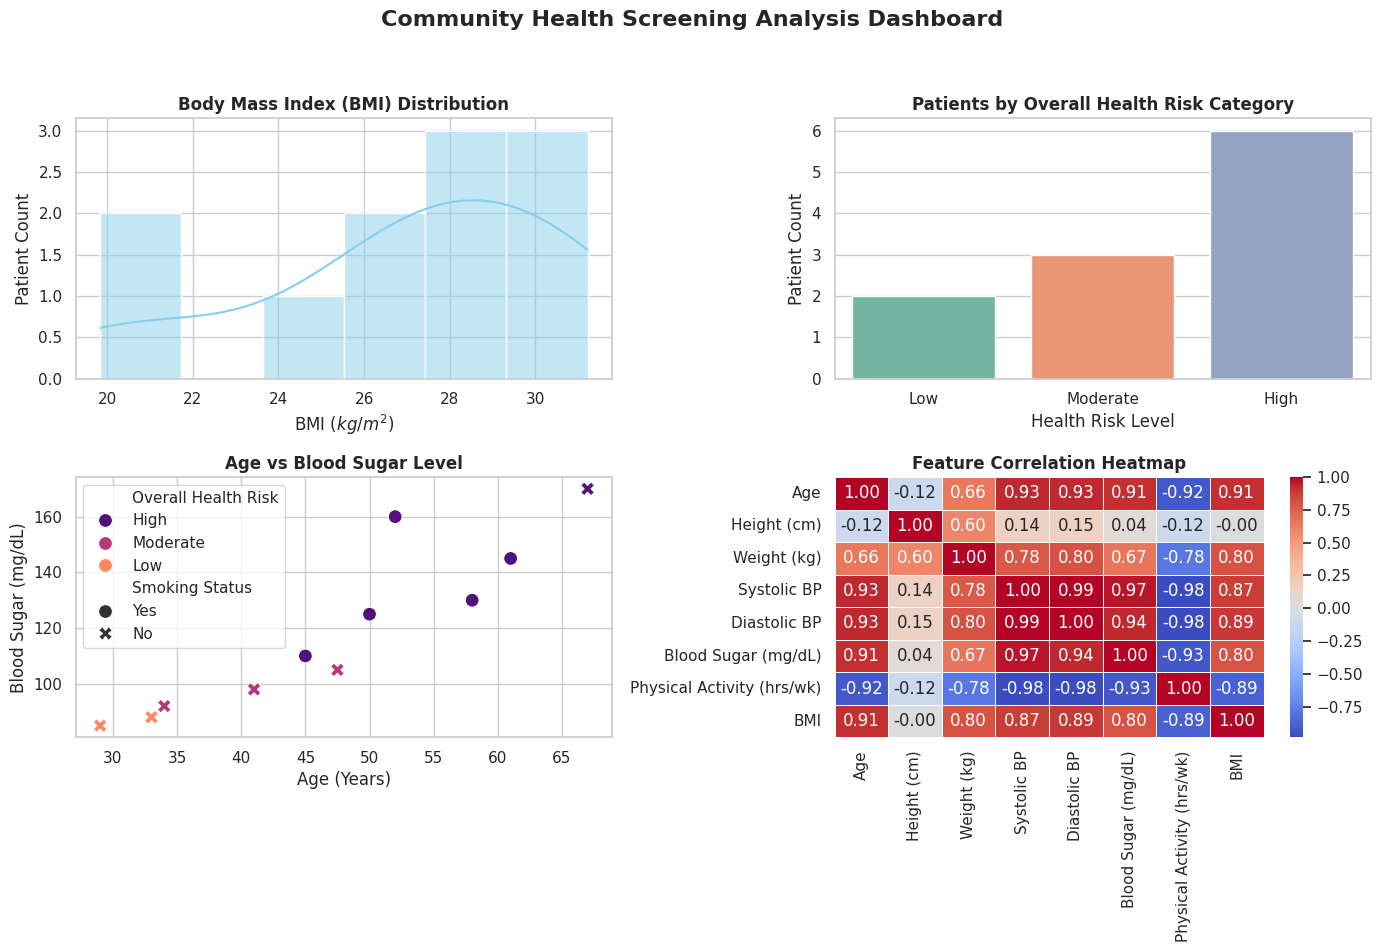

Execution complete. All tasks executed successfully.


In [3]:
"""
Module Name: Module 1: Python Fundamentals for AI
Assignment Title: Community Health Screening Data Analysis System
File Name: module1_health_screening_assignment.py
Author: Academic Researcher & Lecturer
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style for plots
sns.set_theme(style="whitegrid")

# ==============================================================================
# TASK 1: CREATE THE DATASET
# ==============================================================================
print("--- TASK 1: CREATING DATASET ---")

# Raw data dictionary containing 12 patient records (includes missing & duplicates)
raw_data = {
    'Patient ID': [101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 110, 111],
    'Age': [45, 34, 61, 29, 52, np.nan, 41, 58, 33, 50, 50, 67],
    'Gender': ['Male', 'Female', 'Male', 'Female', 'Male', 'Female', 'Male', np.nan, 'Female', 'Male', 'Male', 'Female'],
    'Height (cm)': [175, 160, 168, 165, 180, 158, 172, 165, 170, 178, 178, 155],
    'Weight (kg)': [82, 65, 88, 54, 95, 70, 78, 85, 62, 90, 90, 72],
    'Systolic BP': [135, 118, 145, 110, 150, 125, 128, 140, 115, 138, 138, 155],
    'Diastolic BP': [88, 76, 92, 70, 95, 82, 84, 90, 75, 88, 88, 98],
    'Blood Sugar (mg/dL)': [110, 92, 145, 85, 160, 105, 98, 130, 88, 125, 125, 170],
    'Physical Activity (hrs/wk)': [2.5, 4.0, 1.0, 5.0, 0.5, 3.0, 2.0, 1.5, 4.5, 2.0, 2.0, 0.0],
    'Smoking Status': ['Yes', 'No', 'Yes', 'No', 'Yes', 'No', 'No', 'Yes', 'No', 'Yes', 'Yes', 'No']
}

# Convert dictionary to DataFrame
df = pd.DataFrame(raw_data)

# Display the first five records
print("First 5 records of initial dataset:")
print(df.head())
print("\n" + "="*50 + "\n")


# ==============================================================================
# TASK 2: DATA CLEANING
# ==============================================================================
print("--- TASK 2: DATA CLEANING ---")

# 1. Remove duplicates
initial_count = len(df)
df = df.drop_duplicates(subset=['Patient ID']).reset_index(drop=True)
print(f"Removed {initial_count - len(df)} duplicate record(s).")

# 2. Impute missing numerical values with median
numerical_cols = ['Age', 'Height (cm)', 'Weight (kg)', 'Systolic BP',
                  'Diastolic BP', 'Blood Sugar (mg/dL)', 'Physical Activity (hrs/wk)']

for col in numerical_cols:
    if df[col].isnull().sum() > 0:
        median_val = df[col].median()
        df[col] = df[col].fillna(median_val)
        print(f"Imputed missing values in '{col}' with median: {median_val}")

# 3. Impute missing categorical values with mode (most frequent value)
categorical_cols = ['Gender', 'Smoking Status']

for col in categorical_cols:
    if df[col].isnull().sum() > 0:
        mode_val = df[col].mode()[0]
        df[col] = df[col].fillna(mode_val)
        print(f"Imputed missing values in '{col}' with mode: {mode_val}")

# 4. Verify no missing values remain
missing_count = df.isnull().sum().sum()
print(f"Total missing values remaining in dataset: {missing_count}")
print("\nCleaned DataFrame overview:")
print(df.info())
print("\n" + "="*50 + "\n")


# ==============================================================================
# TASK 3: CREATE HEALTH INDICATORS
# ==============================================================================
print("--- TASK 3: CREATING HEALTH INDICATORS ---")

# User-defined function to calculate BMI
def calculate_bmi(weight, height_cm):
    height_m = height_cm / 100.0
    return weight / (height_m ** 2)

# User-defined function to categorize BMI
def get_bmi_category(bmi):
    if bmi < 18.5:
        return 'Underweight'
    elif 18.5 <= bmi < 25.0:
        return 'Normal weight'
    elif 25.0 <= bmi < 30.0:
        return 'Overweight'
    else:
        return 'Obese'

# User-defined function to categorize Blood Pressure
def get_bp_category(row):
    systolic = row['Systolic BP']
    diastolic = row['Diastolic BP']

    if systolic < 120 and diastolic < 80:
        return 'Normal'
    elif 120 <= systolic <= 129 and diastolic < 80:
        return 'Elevated'
    elif 130 <= systolic <= 139 or 80 <= diastolic <= 89:
        return 'Hypertension Stage 1'
    else:
        return 'Hypertension Stage 2'

# User-defined function to calculate Overall Health Risk
def get_overall_health_risk(row):
    risk_points = 0

    # BMI Risk Factor
    if row['BMI Category'] in ['Overweight', 'Obese']:
        risk_points += 1

    # BP Risk Factor
    if row['BP Category'] in ['Hypertension Stage 1', 'Hypertension Stage 2']:
        risk_points += 1

    # Blood Sugar Risk Factor
    if row['Blood Sugar (mg/dL)'] >= 126:  # Diabetic threshold
        risk_points += 1

    # Smoking Risk Factor
    if row['Smoking Status'] == 'Yes':
        risk_points += 1

    # Map points to Risk Levels
    if risk_points == 0:
        return 'Low'
    elif risk_points in [1, 2]:
        return 'Moderate'
    else:
        return 'High'

# Apply functions to DataFrame
df['BMI'] = calculate_bmi(df['Weight (kg)'], df['Height (cm)'])
df['BMI Category'] = df['BMI'].apply(get_bmi_category)
df['BP Category'] = df.apply(get_bp_category, axis=1)
df['Overall Health Risk'] = df.apply(get_overall_health_risk, axis=1)

print(df[['Patient ID', 'BMI', 'BMI Category', 'BP Category', 'Overall Health Risk']].head())
print("\n" + "="*50 + "\n")


# ==============================================================================
# TASK 4: NUMPY ANALYSIS
# ==============================================================================
print("--- TASK 4: NUMPY STATISTICAL ANALYSIS ---")

# Extract series into NumPy arrays
bmi_array = df['BMI'].to_numpy()
blood_sugar_array = df['Blood Sugar (mg/dL)'].to_numpy()

# BMI Calculations
print(f"BMI Mean:               {np.mean(bmi_array):.2f}")
print(f"BMI Minimum:            {np.min(bmi_array):.2f}")
print(f"BMI Maximum:            {np.max(bmi_array):.2f}")
print(f"BMI Std Dev:            {np.std(bmi_array):.2f}\n")

# Blood Sugar Calculations
print(f"Blood Sugar Mean:       {np.mean(blood_sugar_array):.2f} mg/dL")
print(f"Blood Sugar Minimum:    {np.min(blood_sugar_array):.2f} mg/dL")
print(f"Blood Sugar Maximum:    {np.max(blood_sugar_array):.2f} mg/dL")
print(f"Blood Sugar Std Dev:    {np.std(blood_sugar_array):.2f} mg/dL")
print("\n" + "="*50 + "\n")


# ==============================================================================
# TASK 5: DATA ANALYSIS USING PANDAS
# ==============================================================================
print("--- TASK 5: PANDAS GROUPING & FILTERING ---")

# 1. Average BMI and Blood Sugar by Gender
avg_by_gender = df.groupby('Gender')[['BMI', 'Blood Sugar (mg/dL)']].mean()
print("1. Average BMI and Blood Sugar by Gender:")
print(avg_by_gender.round(2))
print()

# 2. Patient counts by BMI Category and Health Risk Category
patients_by_bmi_cat = df['BMI Category'].value_counts()
patients_by_risk_cat = df['Overall Health Risk'].value_counts()

print("2a. Patient Count by BMI Category:")
print(patients_by_bmi_cat)
print("\n2b. Patient Count by Overall Health Risk Category:")
print(patients_by_risk_cat)
print()

# 3. Average Age by Gender
avg_age_by_gender = df.groupby('Gender')['Age'].mean()
print("3. Average Age by Gender:")
print(avg_age_by_gender.round(2))
print()

# 4. Percentage of Smokers
smoker_pct = (df['Smoking Status'].value_counts(normalize=True).get('Yes', 0)) * 100
print(f"4. Percentage of Smokers in Community: {smoker_pct:.2f}%")
print("\n" + "="*50 + "\n")


# ==============================================================================
# TASK 6: DATA VISUALIZATION
# ==============================================================================
print("--- TASK 6: GENERATING VISUALIZATIONS ---")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Community Health Screening Analysis Dashboard', fontsize=16, fontweight='bold')

# Chart 1: BMI Distribution Histogram
sns.histplot(df['BMI'], kde=True, ax=axes[0, 0], color='skyblue', bins=6)
axes[0, 0].set_title('Body Mass Index (BMI) Distribution', fontweight='bold')
axes[0, 0].set_xlabel('BMI ($kg/m^2$)')
axes[0, 0].set_ylabel('Patient Count')

# Chart 2: Health Risk Category Bar Chart
risk_order = ['Low', 'Moderate', 'High']
sns.countplot(data=df, x='Overall Health Risk', order=risk_order, ax=axes[0, 1], palette='Set2')
axes[0, 1].set_title('Patients by Overall Health Risk Category', fontweight='bold')
axes[0, 1].set_xlabel('Health Risk Level')
axes[0, 1].set_ylabel('Patient Count')

# Chart 3: Age vs Blood Sugar Scatter Plot
sns.scatterplot(data=df, x='Age', y='Blood Sugar (mg/dL)', hue='Overall Health Risk',
                style='Smoking Status', s=100, ax=axes[1, 0], palette='magma')
axes[1, 0].set_title('Age vs Blood Sugar Level', fontweight='bold')
axes[1, 0].set_xlabel('Age (Years)')
axes[1, 0].set_ylabel('Blood Sugar (mg/dL)')

# Chart 4: Correlation Heatmap
numeric_df = df.select_dtypes(include=[np.number]).drop(columns=['Patient ID'])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, ax=axes[1, 1])
axes[1, 1].set_title('Feature Correlation Heatmap', fontweight='bold')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

print("Execution complete. All tasks executed successfully.")

In [2]:
# Access the GitHub token from Colab secrets
from google.colab import userdata

GITHUB_TOKEN = userdata.get('GITHUB_TOKEN')

# Configure Git with your username and email
!git config --global user.email "banteamlak1888@example.com" # Replace with your GitHub email
!git config --global user.name "banteamlak1888" # Replace with your GitHub username

print("Git configured successfully. Remember to replace the placeholder email and username.")

Git configured successfully. Remember to replace the placeholder email and username.


In [6]:
# Clone your repository
# Replace 'your_github_username' and 'your_repository_name' with your actual details.
repo_url = f"https://{GITHUB_TOKEN}@github.com/banteamlak1888/Floridan-University-Fundamentals-AI-Trianing.git"
repo_dir = "Floridan-University-Fundamentals-AI-Trianing" # This is the local folder name Colab will create for your repo

# Remove the directory if it already exists to ensure a clean clone
!rm -rf {repo_dir}

!git clone {repo_url}

print(f"Repository '{repo_dir}' cloned successfully. You can now navigate into it.")
%cd {repo_dir}

Cloning into 'Floridan-University-Fundamentals-AI-Trianing'...
Repository 'Floridan-University-Fundamentals-AI-Trianing' cloned successfully. You can now navigate into it.
/content/Floridan-University-Fundamentals-AI-Trianing


In [9]:

!git add "Fundamentals for AI.ipynb"

# Commit the changes
!git commit -m "Add initial version of Fundamental AI training notebook" # Customize your commit message

!git push origin main

print("Notebook pushed to GitHub successfully!")

fatal: pathspec 'Fundamentals for AI.ipynb' did not match any files
On branch main

Initial commit

nothing to commit (create/copy files and use "git add" to track)
error: src refspec main does not match any
error: failed to push some refs to 'https://github.com/banteamlak1888/Floridan-University-Fundamentals-AI-Trianing.git'
Notebook pushed to GitHub successfully!


**Important:** Remember to replace all placeholder values (`your_email@example.com`, `Your GitHub Username`, `your_github_username`, `your_repository_name`, `your_notebook_name.ipynb`, `main`) with your actual GitHub details and file names.